# Kepler Analysis - Compute Earth's Orbit from Mars and LOS Data

This notebook extends our Kepler analysis series by determining Earth's heliocentric position using Mars and Sun ephemeris data along with Mars orbit measurements. By using the observed ecliptic longitudes of Mars and the Sun, we solve for the Earth-Sun distance such that Earth observes Mars along the correct line-of-sight.

**Contact:** Luca.Canali@cern.ch  
**Date:** February 2025

---
**Key Steps:**

- **Data Ingestion & Filtering:**  
  - Load the ephemeris data from `ephemeris_mars_sun.csv`.
  - Select observations at intervals of 687 days (one Mars year), as Mars will occupy the same position in the solar system for all those observations

- **Earth Position Computation:**  
  - For each selected observation, compute Earth's heliocentric position by solving for the Earth-Sun distance using the observed Sun and Mars ecliptic longitudes and the estimated Mars position (found in notebook 3 of this series "Compute Mars Orbit")
  - Utilize a numerical solver (via `fsolve`) to ensure that the computed Earth position yields the correct LOS angle towards Mars.

- **Ellipse Fit to Earth's Orbit:**  
  - Fit the computed Earth positions to an elliptical model (with the Sun at one focus) using non-linear least squares (`curve_fit`).
  - Extract the orbital parameters (semi-major axis and eccentricity) and compare them with accepted values.

- **Visualization:**  
  - Plot the computed Earth positions, the fixed Mars position, and the Sun at the origin.
  - Overlay the fitted ellipse to visually assess how well it represents Earth's orbit.


## Compute Earth Position from Mars position and line-of-sight data for Mars and the Sun
This is a proof-of-concept for the method, just using the obersations of 1 data point and the subsequent ones space by 1 mars year (687 days)

In [1]:
import pandas as pd
import numpy as np
from scipy.optimize import fsolve, curve_fit

# ----------------------------
# 1. Load and select the data
# ----------------------------
folder = "../Data/"
csv_filename = "ephemeris_mars_sun.csv"
df = pd.read_csv(folder + csv_filename)
df["Date"] = pd.to_datetime(df["Date"])

# Select observations with an exact date match every 687 days (1 Mars year)
start_date = pd.to_datetime("2000-01-01")
interval = pd.Timedelta(days=687)
selected_obs = []
current_date = start_date

max_date = df["Date"].max()
current_date = start_date

while current_date <= max_date:
    candidates = df[df["Date"] == current_date]
    if not candidates.empty:
        selected_obs.append(candidates.iloc[0])
    current_date += interval

# Reset index so we only have our selected observations
selected_df = pd.DataFrame(selected_obs).reset_index(drop=True)
print("Selected observations:")
print(selected_df[["Date", "Mars Ecliptic Longitude (deg)", "Sun Ecliptic Longitude (deg)"]])

# ----------------------------
# 2. Define function to compute Earth's position
# ----------------------------
def compute_earth_position(row, Mars_pos):
    """
    Given a row with observed Sun and Mars ecliptic longitudes,
    compute Earth’s heliocentric position E = (r*cos L_E, r*sin L_E) so that:
      - The Earth sees the Sun in the direction given by L_Sun.
      - The Earth sees Mars (at fixed position Mars_pos) in the direction given by L_Mars.
    """
    L_sun = row["Sun Ecliptic Longitude (deg)"]
    L_mars = row["Mars Ecliptic Longitude (deg)"]
    
    # Earth sees the Sun in the opposite direction to the Sun’s heliocentric position:
    L_earth = (L_sun - 180) % 360
    L_earth_rad = np.radians(L_earth)
    
    def angle_deg(vec):
        return (np.degrees(np.arctan2(vec[1], vec[0])) + 360) % 360
    
    def residual(r):
        # Make sure r is treated as a scalar and always return a one-element array
        r_val = np.atleast_1d(r)[0]
        # Earth lies on the ray defined by L_earth:
        E = np.array([r_val * np.cos(L_earth_rad), r_val * np.sin(L_earth_rad)])
        # Geocentric vector (from Earth to Mars)
        V = Mars_pos - E
        # Angular difference (wrapped to [-180, 180])
        diff = (angle_deg(V) - L_mars + 180) % 360 - 180
        return np.array([diff])
    
    # Solve for r (initial guess: 1 AU)
    r_solution, = fsolve(residual, 1.0)
    E = np.array([r_solution * np.cos(L_earth_rad), r_solution * np.sin(L_earth_rad)])
    
    return pd.Series({"Earth_x": E[0],
                      "Earth_y": E[1],
                      "r": r_solution,
                      "Earth_Longitude": L_earth})


Selected observations:
         Date  Mars Ecliptic Longitude (deg)  Sun Ecliptic Longitude (deg)
0  2000-01-01                     327.579360                    279.863105
1  2001-11-18                     314.876855                    235.687620
2  2003-10-06                     330.574687                    192.280233
3  2005-08-23                      43.348827                    149.891794
4  2007-07-11                      41.399396                    108.242799
5  2009-05-28                      26.949060                     66.679698
6  2015-01-18                     334.146195                    297.338909
7  2016-12-05                     318.918549                    253.044608
8  2018-10-23                     315.965215                    209.270244
9  2020-09-09                      27.850830                    166.490047
10 2022-07-28                      45.154135                    124.619839


In [2]:
# Define Mars position (fixed for this example)

Mars_pos = np.array([1.387911, -0.007656])

# ----------------------------
# 3. Apply the function to each selected observation
# ----------------------------
results = selected_df.apply(compute_earth_position, axis=1, Mars_pos=Mars_pos)
# Reset indices on both DataFrames to ensure proper alignment
selected_df = pd.concat([selected_df.reset_index(drop=True), results.reset_index(drop=True)], axis=1)
print("\nComputed Earth positions:")
print(selected_df[["Date", "Earth_x", "Earth_y", "r", "Earth_Longitude"]])


Computed Earth positions:
         Date   Earth_x   Earth_y         r  Earth_Longitude
0  2000-01-01 -0.170789  0.982313  0.997050        99.863105
1  2001-11-18  0.561325  0.822490  0.995779        55.687620
2  2003-10-06  0.991650  0.215856  1.014871        12.280233
3  2005-08-23  0.864787 -0.501465  0.999662       329.891794
4  2007-07-11  0.314454 -0.954015  1.004503       288.242799
5  2009-05-28 -0.393793 -0.913485  0.994750       246.679698
6  2015-01-18 -0.458655  0.887149  0.998698       117.338909
7  2016-12-05  0.289589  0.949846  0.993010        73.044608
8  2018-10-23  0.873578  0.489633  1.001439        29.270244
9  2020-09-09  0.964035 -0.231621  0.991469       346.490047
10 2022-07-28  0.571764 -0.828206  1.006399       304.619839


In [3]:
# ----------------------------
# 4. Fit the calculated Earth positions with an ellipse (Sun at one focus)
# ----------------------------
def ellipse_polar(theta, a, e, phi):
    return a * (1 - e**2) / (1 + e * np.cos(theta - phi))

# Get polar coordinates (with Sun at (0,0))
E_x = selected_df["Earth_x"].values
E_y = selected_df["Earth_y"].values
r_data = np.sqrt(E_x**2 + E_y**2)
theta_data = np.arctan2(E_y, E_x)

# Initial guesses for the ellipse parameters
a_guess = np.mean(r_data)
e_guess = 0.0167
phi_guess = 0.0
initial_guess = [a_guess, e_guess, phi_guess]

popt, pcov = curve_fit(ellipse_polar, theta_data, r_data, p0=initial_guess)
a_fit, e_fit, phi_fit = popt
print("\nFitted ellipse parameters:")
print("Semi-major axis (a) =", a_fit)
print("Eccentricity (e) =", e_fit)
print("Orientation offset (phi) =", phi_fit)

# Generate fitted ellipse points for visualization
theta_fit = np.linspace(-np.pi, np.pi, 360)
r_fit = ellipse_polar(theta_fit, *popt)
x_fit = r_fit * np.cos(theta_fit)
y_fit = r_fit * np.sin(theta_fit)



Fitted ellipse parameters:
Semi-major axis (a) = 0.9984139869068877
Eccentricity (e) = -0.004145308799435642
Orientation offset (phi) = -0.40763381285477396


## Fit an ellipse and plot

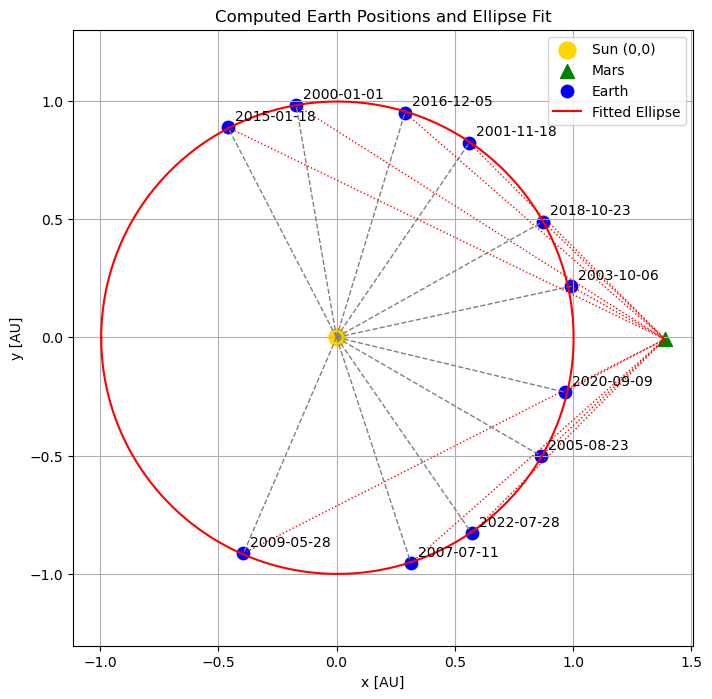

In [4]:
# ----------------------------
# 5. Visualization
# ----------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

# Plot the Sun
plt.scatter(0, 0, c='gold', s=150, label="Sun (0,0)")

# Plot Mars in green instead of red
plt.scatter(Mars_pos[0], Mars_pos[1], c='green', marker='^', s=100, label="Mars")

# Plot Earth positions
plt.scatter(selected_df["Earth_x"], selected_df["Earth_y"], c='blue', marker='o', s=80, label="Earth")

# For each Earth position, draw lines to the Sun and Mars and add annotations
for idx, row in selected_df.iterrows():
    earth_x, earth_y = row["Earth_x"], row["Earth_y"]
    
    # Dashed grey line from Earth to Sun
    plt.plot([0, earth_x], [0, earth_y], linestyle='--', color='grey', linewidth=1)
    
    # Dotted grey line from Earth to Mars
    plt.plot([earth_x, Mars_pos[0]], [earth_y, Mars_pos[1]], linestyle=':', color='red', linewidth=1)
    
    # Annotate the Earth positions with the corresponding date (offset for clarity)
    plt.annotate(row["Date"].date(), (earth_x, earth_y), textcoords="offset points", xytext=(5,5))

# Plot the fitted ellipse
plt.plot(x_fit, y_fit, 'r-', label="Fitted Ellipse")

plt.xlabel("x [AU]")
plt.ylabel("y [AU]")
plt.title("Computed Earth Positions and Ellipse Fit")
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()


## Calculate Earth orbit using all the available data

In [5]:
import pandas as pd
import numpy as np
from scipy.optimize import fsolve

# ----------------------------
# 1. Load the data files
# ----------------------------
folder = "../Data/"

# Load computed Mars orbit data
df_mars = pd.read_csv(folder + "computed_Mars_orbit.csv")
df_mars["Date"] = pd.to_datetime(df_mars["Start_Date"])
df_mars.drop(columns=["Start_Date"], inplace=True)

# Load ephemeris data (contains Sun, Mars ecliptic longitudes and Angular Separation (deg))
df_ephem = pd.read_csv(folder + "ephemeris_mars_sun.csv")
df_ephem["Date"] = pd.to_datetime(df_ephem["Date"])

# ----------------------------
# 2. Define function to compute Earth's heliocentric position
# ----------------------------
def compute_earth_position(L_sun, L_mars, Mars_pos, tol=1e-6):
    """
    Computes Earth's heliocentric position given:
      - L_sun: Sun ecliptic longitude (deg)
      - L_mars: Mars ecliptic longitude (deg)
      - Mars_pos: Fixed Mars position as a 2-element array [Mars_X, Mars_Y]
      
    Earth is assumed to lie along the ray opposite the Sun (i.e. L_sun - 180).
    fsolve finds the Earth-Sun distance r such that the angle from Earth to Mars
    matches the observed Mars longitude.
    
    If the solver does not converge or the residual error exceeds tol,
    returns (None, None, None).
    """
    # Compute Earth's ecliptic longitude (opposite to the Sun)
    L_earth = (L_sun - 180) % 360
    L_earth_rad = np.radians(L_earth)
    
    def angle_deg(vec):
        return (np.degrees(np.arctan2(vec[1], vec[0])) + 360) % 360
    
    def residual(r):
        r_val = np.atleast_1d(r)[0]
        # Earth lies along the ray defined by L_earth
        E = np.array([r_val * np.cos(L_earth_rad), r_val * np.sin(L_earth_rad)])
        # Compute the vector from Earth to Mars
        V = Mars_pos - E
        # Angular difference (wrapped to [-180, 180])
        diff = (angle_deg(V) - L_mars + 180) % 360 - 180
        return np.array([diff])
    
    # Solve for the Earth-Sun distance (initial guess: 1 AU)
    sol, infodict, ier, mesg = fsolve(residual, 1.0, full_output=True)
    r_solution = sol[0]
    
    # Check for convergence and if residual error is within tolerance.
    if ier != 1 or np.abs(residual(r_solution)[0]) > tol:
        return None, None, None
    
    E = np.array([r_solution * np.cos(L_earth_rad), r_solution * np.sin(L_earth_rad)])
    return E, r_solution, L_earth

# ----------------------------
# 3. Loop over Mars orbit observations and corresponding ephemeris dates at multiples of 687 days
# ----------------------------
earth_positions_list = []
mars_year = pd.Timedelta(days=687)
max_ephem_date = df_ephem["Date"].max()
angular_sep_tol = 15.0  # degrees: tolerance for skipping points near 180°

# Outer loop: iterate over each Mars orbit observation (base date and Mars position)
for idx, mars_row in df_mars.iterrows():
    base_date = mars_row["Date"]
    Mars_pos = np.array([mars_row["Mars_X"], mars_row["Mars_Y"]])
    
    # Inner loop: iterate over ephemeris observations starting at base_date and then every 687 days
    current_date = base_date
    while current_date <= max_ephem_date:
        # Look for an ephemeris observation on the current date
        ephem_candidates = df_ephem[df_ephem["Date"] == current_date]
        if ephem_candidates.empty:
            current_date += mars_year
            continue
        ephem_row = ephem_candidates.iloc[0]
    
        # Filter based on the "Angular Separation (deg)" field from the ephemeris data.
        angular_sep = ephem_row["Angular Separation (deg)"]
        if abs(angular_sep - 180) < angular_sep_tol:
            current_date += mars_year
            continue

        # Extract required parameters from the ephemeris observation
        L_sun = ephem_row["Sun Ecliptic Longitude (deg)"]
        L_mars = ephem_row["Mars Ecliptic Longitude (deg)"]
    
        # Compute Earth's heliocentric position for the current date
        E, r_solution, L_earth = compute_earth_position(L_sun, L_mars, Mars_pos)
    
        # Discard the point if Earth position was not computed accurately
        if E is None:
            current_date += mars_year
            continue
        
        earth_positions_list.append({
            "Ephem_date": current_date,
            "Mars_X": Mars_pos[0],
            "Mars_Y": Mars_pos[1],
            "Earth_x": E[0],
            "Earth_y": E[1],
            "r": r_solution,
            "Angular_Separation (deg)": angular_sep
        })
        
        # Move to the next ephemeris observation date (one Mars year later)
        current_date += mars_year

# Accumulate all computed positions into a DataFrame and order by Ephem_date
df_earth_positions = pd.DataFrame(earth_positions_list)
df_earth_positions.sort_values(by="Ephem_date", inplace=True)

print(df_earth_positions)


     Ephem_date    Mars_X    Mars_Y   Earth_x   Earth_y         r  \
0    2000-01-01  1.387911 -0.007656 -0.170789  0.982313  0.997050   
11   2000-01-02  1.390132  0.006632 -0.188291  0.979394  0.997330   
21   2000-01-03  1.391546  0.020397 -0.205512  0.975057  0.996479   
32   2000-01-04  1.391945  0.035610 -0.222876  0.971452  0.996691   
43   2000-01-05  1.392190  0.050820 -0.240178  0.967540  0.996905   
...         ...       ...       ...       ...       ...       ...   
6860 2022-07-25  1.384593 -0.053520  0.529604 -0.855734  1.006360   
6870 2022-07-26  1.385745 -0.038333  0.543804 -0.846791  1.006369   
6880 2022-07-27  1.386745 -0.023141  0.557855 -0.837609  1.006375   
10   2022-07-28  1.387911 -0.007656  0.571764 -0.828206  1.006399   
6890 2022-07-28  1.387593 -0.007947  0.571753 -0.828189  1.006379   

      Angular_Separation (deg)  
0                    47.716254  
11                   47.472494  
21                   47.228668  
32                   46.984779  
43    

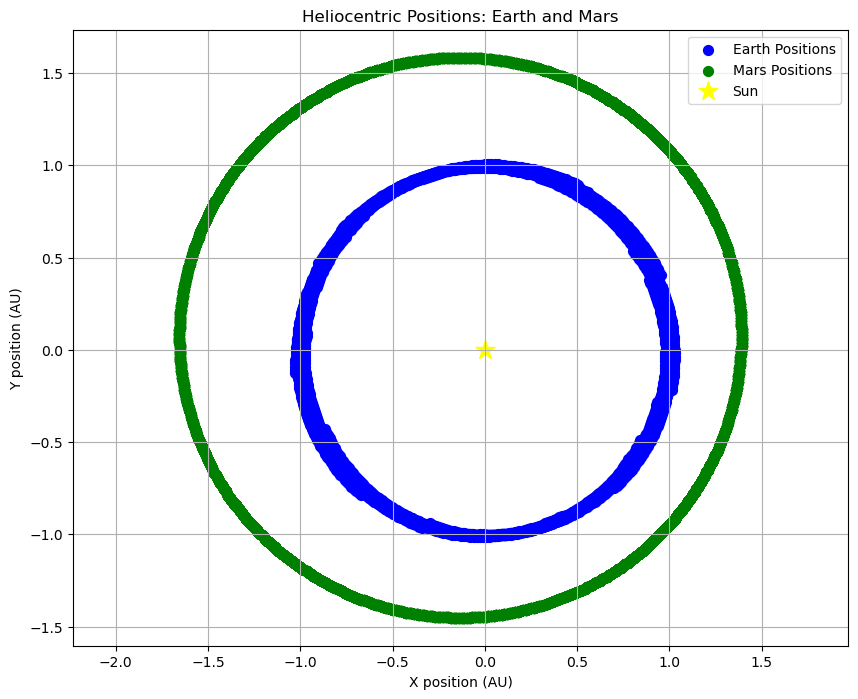

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Plot Earth's computed positions in blue
plt.scatter(df_earth_positions["Earth_x"], df_earth_positions["Earth_y"],
            color='blue', label='Earth Positions', s=50)

# Plot Mars positions in green
plt.scatter(df_earth_positions["Mars_X"], df_earth_positions["Mars_Y"],
            color='green', label='Mars Positions', s=50)

# Plot the Sun at the origin (0, 0)
plt.scatter(0, 0, color='yellow', marker='*', s=200, label='Sun')

plt.xlabel("X position (AU)")
plt.ylabel("Y position (AU)")
plt.title("Heliocentric Positions: Earth and Mars")
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()


## Fit measured Earth positions with and ellipse

Fitted ellipse parameters:
Semi-major axis (a): 1.0008384418812508
Eccentricity (e): -0.006536776980136791
Orientation (omega, in radians): -1.303630909899905


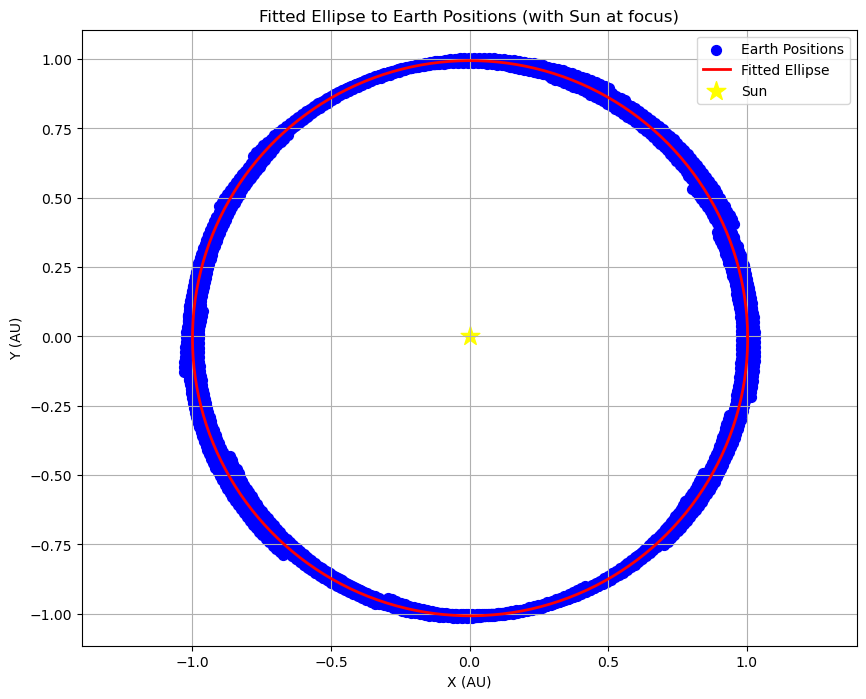

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- Extract Earth positions from the DataFrame ---
# Assumes df_earth_positions is already defined with columns "Earth_x" and "Earth_y"
x = df_earth_positions["Earth_x"].values
y = df_earth_positions["Earth_y"].values

# Convert Earth positions (x,y) to polar coordinates (r, theta) with Sun at (0,0)
r_obs = np.sqrt(x**2 + y**2)
theta_obs = np.arctan2(y, x)

# --- Define the ellipse model in polar form ---
def ellipse_model(theta, a, e, omega):
    """
    Polar equation for an ellipse with a focus at the origin.
    
    Parameters:
      theta : angle (radians)
      a     : semi-major axis
      e     : eccentricity
      omega : orientation (argument of perihelion)
      
    Returns:
      r : distance corresponding to theta.
    """
    return a * (1 - e**2) / (1 + e * np.cos(theta - omega))

# Initial parameter guess: a ~ 1 AU, e ~ 0.0167 (Earth's eccentricity), omega = 0
p0 = [1.0, 0.0167, 0.0]

# --- Fit the ellipse model to the observed data ---
popt, pcov = curve_fit(ellipse_model, theta_obs, r_obs, p0=p0)
a_fit, e_fit, omega_fit = popt

print("Fitted ellipse parameters:")
print("Semi-major axis (a):", a_fit)
print("Eccentricity (e):", e_fit)
print("Orientation (omega, in radians):", omega_fit)

# --- Generate the fitted ellipse curve for plotting ---
theta_fit = np.linspace(0, 2*np.pi, 360)
r_fit = ellipse_model(theta_fit, *popt)
x_fit = r_fit * np.cos(theta_fit)
y_fit = r_fit * np.sin(theta_fit)

# --- Plot the results ---
plt.figure(figsize=(10, 8))
# Earth positions in blue
plt.scatter(x, y, color='blue', label="Earth Positions", s=50)
# Fitted ellipse in red
plt.plot(x_fit, y_fit, color='red', label="Fitted Ellipse", linewidth=2)
# Sun at the origin in yellow
plt.scatter(0, 0, color='yellow', marker='*', s=200, label="Sun")

plt.xlabel("X (AU)")
plt.ylabel("Y (AU)")
plt.title("Fitted Ellipse to Earth Positions (with Sun at focus)")
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()


## Note on the Fitted Earth Orbit Results

The fitted ellipse for Earth's orbit yields a semi-major axis of 1 AU (as expected) and an eccentricity of approximately 0.0065. In contrast, the accepted eccentricity for Earth is around 0.0167. Although there is a discrepancy in the eccentricity values, both measurements underscore that Earth's orbit is nearly circular.
